In [ ]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
# The code below was used to import the TLE data from the API and turn it into a CSV file. If you wish to use the most recent data from the API,
# feel free to create an account on spacetrack.org and imput your email and password into this code. Otherwise, please use the provided 
# leo_analysis.csv file.
""" import json
import pandas as pd
from spacetrack import SpaceTrackClient
import spacetrack.operators as op

st = SpaceTrackClient(identity='address@gmail.com', password='XXXXXXXXXXXX.')

# Fetch the data, null-val decay rate means we are only analysing currently orbiting satellites
leo_raw = st.gp(period=op.inclusive_range(84, 128), decay_date='null-val', format='json')

try:
    # Attempt to parse the data
    data_list = json.loads(leo_raw)
    df = pd.DataFrame(data_list)
    
    # Check if we actually got data
    if not df.empty:
        print("Success! Top 5 Owners:")
        print(df['COUNTRY_CODE'].value_counts().head())
        df.to_csv("leo_analysis.csv", index=False)
    else:
        print("Query successful, but no satellites found in that range.")

except json.JSONDecodeError:
    # If the API returned a text error message instead of JSON data
    print("API Error or Rate Limit Hit. The server said:")
    print(leo_raw) """

' import json\nimport pandas as pd\nfrom spacetrack import SpaceTrackClient\nimport spacetrack.operators as op\n\nst = SpaceTrackClient(identity=\'address@gmail.com\', password=\'XXXXXXXXXXXX.\')\n\n# Fetch the data, null-val decay rate means we are only analysing currently orbiting satellites\nleo_raw = st.gp(period=op.inclusive_range(84, 128), decay_date=\'null-val\', format=\'json\')\n\ntry:\n    # Attempt to parse the data\n    data_list = json.loads(leo_raw)\n    df = pd.DataFrame(data_list)\n\n    # Check if we actually got data\n    if not df.empty:\n        print("Success! Top 5 Owners:")\n        print(df[\'COUNTRY_CODE\'].value_counts().head())\n        df.to_csv("leo_analysis.csv", index=False)\n    else:\n        print("Query successful, but no satellites found in that range.")\n\nexcept json.JSONDecodeError:\n    # If the API returned a text error message instead of JSON data\n    print("API Error or Rate Limit Hit. The server said:")\n    print(leo_raw) '

## I. Problem Definition: Satellite Orbit Classification
In this project, we utilize **Two-Line Element (TLE)** data to distinguish between active payloads and space debris. As the number of tracked objects in Earth's orbit increases, automated classification becomes vital for space situational awareness. 

**Goal:** Implement a **Random Forest Classifier** to predict the `OBJECT_TYPE` based on orbital parameters like eccentricity, apoapsis, and ballistic coefficients.

## II. Data Selection, Investigation, and Preprocessing

In [ ]:
# Load Dataset csv file

# Contains Payload, Debris, Unknown, TBA, and Rocket Body
df = pd.read_csv('leo_analysis.csv')

# Preprocessing removal of identifiers and non-numeric metadata that do not contribute to physical orbital characteristics
df = df.drop(columns=['NORAD_CAT_ID', 'TLE_LINE0', 'GP_ID', 'FILE', 'OBJECT_ID', 'OBJECT_NAME', 'CREATION_DATE'])

# Only Contains Payload and Debris
df_reduced = df[df['OBJECT_TYPE'].isin(['DEBRIS', 'PAYLOAD'])]

# Dara investigation
print(f'Unique Satelite Categories are: {df["OBJECT_TYPE"].unique()} \n')
print(df['OBJECT_TYPE'].value_counts())
df.head()

Unique Satelite Categories are: <StringArray>
['PAYLOAD', 'ROCKET BODY', 'DEBRIS', 'UNKNOWN', 'TBA']
Length: 5, dtype: str 

OBJECT_TYPE
PAYLOAD        15339
DEBRIS         10156
UNKNOWN         1400
ROCKET BODY     1010
TBA              130
Name: count, dtype: int64


,CCSDS_OMM_VERS,COMMENT,ORIGINATOR,CENTER_NAME,REF_FRAME,TIME_SYSTEM,MEAN_ELEMENT_THEORY,EPOCH,MEAN_MOTION,ECCENTRICITY,...,APOAPSIS,PERIAPSIS,OBJECT_TYPE,RCS_SIZE,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,TLE_LINE1,TLE_LINE2
0,3.0,GENERATED VIA SPACE-TRACK.ORG API,18 SPCS,EARTH,TEME,UTC,SGP4,2026-04-13T07:01:10.958880,11.903476,0.144432,...,2894.631,554.108,PAYLOAD,MEDIUM,US,1959-02-17,AFETR,NaN,1 00011U 59001A 26103.29248795 .00000796 0...,2 00011 32.8673 330.7473 1444321 47.5661 323...
1,3.0,GENERATED VIA SPACE-TRACK.ORG API,18 SPCS,EARTH,TEME,UTC,SGP4,2026-04-13T07:07:55.894080,11.485950,0.164627,...,3285.577,553.534,ROCKET BODY,MEDIUM,US,1959-02-17,AFETR,NaN,1 00012U 59001B 26103.29717470 .00000211 0...,2 00012 32.8962 93.9114 1646267 121.5399 255...
2,3.0,GENERATED VIA SPACE-TRACK.ORG API,18 SPCS,EARTH,TEME,UTC,SGP4,2026-04-13T04:48:54.741312,11.619216,0.163730,...,3204.163,507.811,PAYLOAD,MEDIUM,US,1959-09-18,AFETR,NaN,1 00020U 59007A 26103.20063358 .00000386 0...,2 00020 33.3387 140.9176 1637304 65.1838 310...
3,3.0,GENERATED VIA SPACE-TRACK.ORG API,18 SPCS,EARTH,TEME,UTC,SGP4,2026-04-13T06:37:05.188800,15.276230,0.007977,...,537.654,428.191,PAYLOAD,MEDIUM,US,1959-10-13,AFETR,NaN,1 00022U 59009A 26103.27575450 .00006199 0...,2 00022 50.2441 60.7846 0079771 222.8855 136...
4,3.0,GENERATED VIA SPACE-TRACK.ORG API,18 SPCS,EARTH,TEME,UTC,SGP4,2026-04-12T22:15:17.030016,14.786947,0.002230,...,649.084,617.814,PAYLOAD,MEDIUM,US,1960-04-01,AFETR,NaN,1 29U 60002B 26102.92728044 .00000271 0...,2 29 48.3796 334.7736 0022299 346.5924 13...


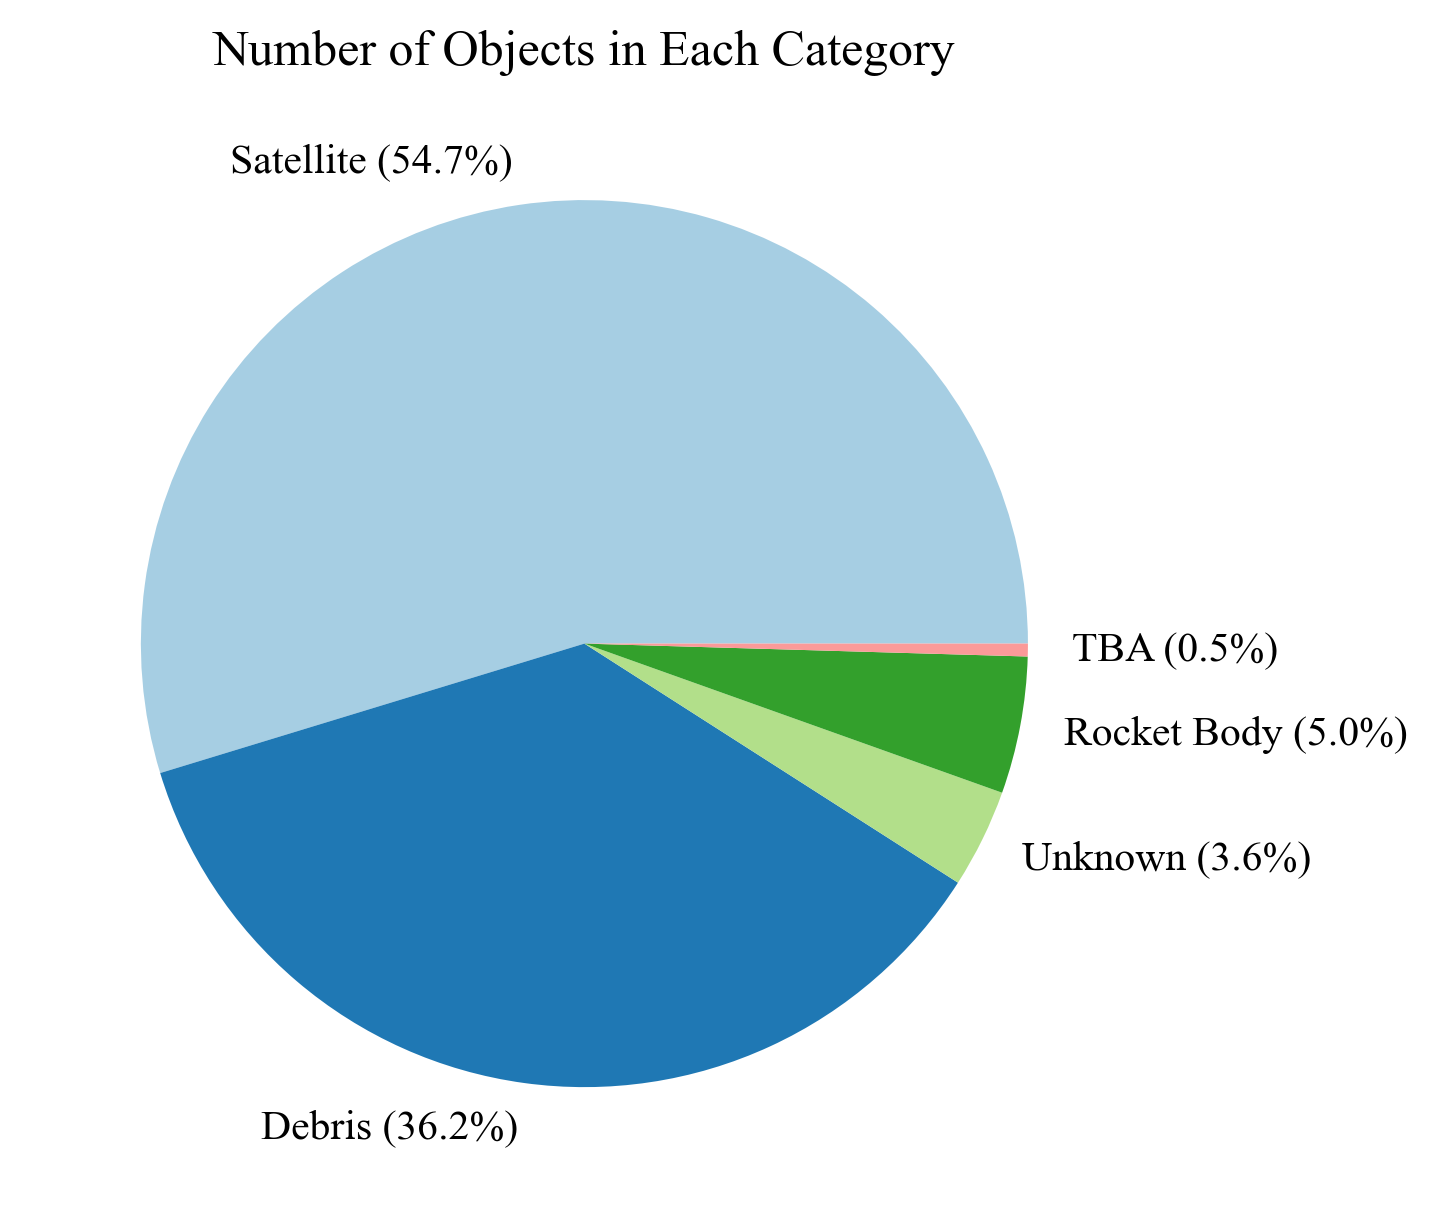

In [ ]:
# Create a visual breakdown of number of objects in each class

# Set fonts
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

# Chart Resolution and custom co,ors
plt.figure(dpi=300)
customColors = plt.get_cmap('Paired').colors[:6]

# Data labels and sizes
totalNum = len(df)
raw_labels = ['Satellite', 'Debris', 'Unknown', 'Rocket Body', 'TBA']
sizes = [
    len(df[df['OBJECT_TYPE'] == 'PAYLOAD'])/totalNum*100,
    len(df[df['OBJECT_TYPE'] == 'DEBRIS'])/totalNum*100,
    len(df[df['OBJECT_TYPE'] == 'ROCKET BODY'])/totalNum*100,
    len(df[df['OBJECT_TYPE'] == 'UNKNOWN'])/totalNum*100,
    len(df[df['OBJECT_TYPE'] == 'TBA'])/totalNum*100
]

# Format labels to include percentage points in parentheses
labels = [f"{label} ({size:.1f}%)" for label, size in zip(raw_labels, sizes)]

# Create the pie chart
plt.pie(sizes, labels=labels, colors=customColors)

# Display the chart 
plt.title("Number of Objects in Each Category", loc='center')
plt.show() 

## III. Data Mining Methods
- Define X (feature matrix) and y (target vector)
- Perform the train and test split
- Run the Random Forest Classifiers, with a balanced hyperparameter due to imbalanced dataset

In [ ]:
# Since the Random Forest Algorithm only takes numerical values for X, we assign X as the database parameters that are numeric.
# Fruthermore, all of our parameters of interest are numeric, so this choice makes sense.
# Had they been non-numeric as well, would have had to one-hot encode.

X = df.select_dtypes(include=['number'])
print(X)
y = df['OBJECT_TYPE']
print(y)

# Only Debris and Payload
X_reduced = df_reduced.select_dtypes(include=['number'])
y_reduced = df_reduced['OBJECT_TYPE']
print(y_reduced)

       CCSDS_OMM_VERS  MEAN_MOTION  ECCENTRICITY  INCLINATION  RA_OF_ASC_NODE  \
0                 3.0    11.903476      0.144432      32.8673        330.7473   
1                 3.0    11.485950      0.164627      32.8962         93.9114   
2                 3.0    11.619216      0.163730      33.3387        140.9176   
3                 3.0    15.276230      0.007977      50.2441         60.7846   
4                 3.0    14.786947      0.002230      48.3796        334.7736   
...               ...          ...           ...          ...             ...   
28030             3.0    14.715176      0.014306      88.7449        256.8085   
28031             3.0    14.689549      0.012485      88.4851        237.8715   
28032             3.0    14.346675      0.001598      87.8708        197.8746   
28033             3.0    14.135112      0.021626      88.9165        277.4769   
28034             3.0    15.942440      0.002396      87.9628        294.9979   

       ARG_OF_PERICENTER  M

In [ ]:
# performs the train test split on all 5 categories
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# performs the train test split on reduced debris and payload categories only
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y_reduced, test_size=0.2)

# Set up the model with all 5 categories
rnd_clf = RandomForestClassifier(n_estimators=500, class_weight='balanced', n_jobs=-1) # 5 unique categories, class_weight='balanced', removed max leaf nodes

# Set up the reduced
rnd_clf_reduced = RandomForestClassifier(n_estimators=500, n_jobs=-1)

In [ ]:
# Fit the general model
rnd_clf.fit(X_train, y_train)

# Fit the reduced model
rnd_clf_reduced.fit(X_train_reduced, y_train_reduced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Get the predictions
y_pred = rnd_clf.predict(X_test)
y_pred_reduced = rnd_clf_reduced.predict(X_test_reduced)

## IV. Evaluation and Results

In [ ]:
# Get the classification report to display precision, recall, and the f1-score
from sklearn.metrics import classification_report
print(f'The classification model for the general model is:\n{classification_report(y_test, y_pred)}')
print(f'The classification model for the reduced model is:\n{classification_report(y_test_reduced, y_pred_reduced)}')

The classification model for the general model is:
              precision    recall  f1-score   support

      DEBRIS       0.89      0.96      0.93      1979
     PAYLOAD       0.93      0.97      0.95      3108
 ROCKET BODY       0.71      0.34      0.46       193
         TBA       0.71      0.19      0.30        26
     UNKNOWN       0.89      0.41      0.56       301

    accuracy                           0.91      5607
   macro avg       0.83      0.58      0.64      5607
weighted avg       0.91      0.91      0.90      5607

The classification model for the reduced model is:
              precision    recall  f1-score   support

      DEBRIS       0.97      0.96      0.97      1988
     PAYLOAD       0.98      0.98      0.98      3111

    accuracy                           0.98      5099
   macro avg       0.98      0.97      0.97      5099
weighted avg       0.98      0.98      0.98      5099



Reducing the dataset to just payload and debris improved the performance of the model, specifically by improving the precision of the model.

In [ ]:
# Which features are the most important?

# General
features = pd.DataFrame(rnd_clf.feature_importances_, index=X.columns)
tree_top_10_features = features.sort_values(by=0, ascending=False).head(10)
print(f'The top ten features for the general model are:\n{tree_top_10_features}')

# Reduced
features_reduced = pd.DataFrame(rnd_clf_reduced.feature_importances_, index=X.columns)
tree_top_10_features_reduced = features.sort_values(by=0, ascending=False).head(10)
print(f'The top ten features for the general model are:\n{tree_top_10_features_reduced}')

The top ten features for the general model are:
                        0
ECCENTRICITY     0.147914
BSTAR            0.128690
INCLINATION      0.120236
REV_AT_EPOCH     0.115884
APOAPSIS         0.067281
MEAN_MOTION_DOT  0.063045
PERIAPSIS        0.061740
SEMIMAJOR_AXIS   0.059354
PERIOD           0.057439
MEAN_MOTION      0.054994
The top ten features for the general model are:
                        0
ECCENTRICITY     0.147914
BSTAR            0.128690
INCLINATION      0.120236
REV_AT_EPOCH     0.115884
APOAPSIS         0.067281
MEAN_MOTION_DOT  0.063045
PERIAPSIS        0.061740
SEMIMAJOR_AXIS   0.059354
PERIOD           0.057439
MEAN_MOTION      0.054994


In [ ]:
# Does this make sense?
debris = df.loc[df['OBJECT_TYPE'] == 'DEBRIS']
payload = df.loc[df['OBJECT_TYPE'] == 'PAYLOAD']

print(f'Debris Eccentricity is {debris["ECCENTRICITY"].mean()}')
print(f'Payload Eccentricity is {payload["ECCENTRICITY"].mean()}')

print(f'Debris Balistic Coefficient is {debris["BSTAR"].mean()}')
print(f'Payload Balistic Coefficient is {payload["BSTAR"].mean()}')

print(f'Debris Inclination is {debris["INCLINATION"].mean()}')
print(f'Payload Inclination is {payload["INCLINATION"].mean()}')


Debris Eccentricity is 0.013657807914533282
Payload Eccentricity is 0.0012124118436664711
Debris Balistic Coefficient is 0.001847389236886668
Payload Balistic Coefficient is -1.614604223182731e-05
Debris Inclination is 88.50677459629775
Payload Inclination is 63.22079596453485


As can be seen from the information above, the eccentricities, balistic coefficients, and inclinations between debris and payload classes differ significantly. Thus, it intuitively makes sense that the random forest classifier chose those three parameters as the top features to split over. It is important to note that if you run the code multiple times, you will see that the balistic coefficient and inclination switch places in terms of importance, but eccentricity remains as the top feature. This makes sense since, on average, the satellites will maintain their orbits and energy through their trusters, whereas over time, the debris will lose energy, resulting in a more eccentric orbit, making the eccentricity the logical top predictor of the object types.